# 🧠 EMG RMS SVR Training

This notebook implements a **Support Vector Regressor (SVR)** using **Root Mean Square (RMS)** feature extraction from 8-channel EMG signals, as is common for real-time control applications.

## 1. Import Libraries and Define Constants

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
from constants import WINDOW_SIZE, STRIDE, WINDOW_MS, HP_CUTOFF_FREQ, N_CHANNELS, FS, HP_ORDER

# --- Feature extraction ---
from feature_extraction.rms import preprocess_force_rms

# --- Sklearn / ML utilities ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import r2_score  # for regression evaluation
import joblib  # for saving/loading models

print("✅ Libraries imported successfully.")

# --- Data files ---
DATA_FILES = [
     "../myo/samples/raymond_no_force.csv",
    "../myo/samples/raymond_force_0.csv",
    "../myo/samples/raymond_force_10.csv",    # 0.35 kg
    "../myo/samples/raymond_force_20.csv",    # 0.70 kg
    "../myo/samples/raymond_force_30.csv",    # 1.05 kg
    "../myo/samples/raymond_force_40.csv",    # 1.40 kg
    "../myo/samples/raymond_force_50.csv",    # 1.75 kg
    "../myo/samples/raymond_force_60.csv",    # 2.10 kg
    "../myo/samples/raymond_force_70.csv",    # 2.45 kg
    "../myo/samples/raymond_force_80.csv",    # 2.80 kg
    "../myo/samples/raymond_force_90.csv",    # 3.15 kg
    "../myo/samples/raymond_force_100.csv",   # 3.50 kg
]


✅ Libraries imported successfully.


## 2. Feature Extraction and Model Definition
*(This logic is now defined in `feature_extraction/*`)*

In [7]:
print("Preprocessing functions imported from feature_extraction/")

Preprocessing functions imported from feature_extraction/


## 3. Load, Preprocess, and Split Data

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X_all = []
Y_all = []

print(f"Feature extraction parameters: Window size = {WINDOW_MS}ms ({WINDOW_SIZE} samples), High-pass filter = {HP_CUTOFF_FREQ}Hz")
print("Processing all data files (Filter and RMS extraction)...")

for path in DATA_FILES:
    print(f"Processing file: {path}")

    X_rms, Y_rms = preprocess_force_rms(path, force_scale_to_percent=False)

    print(X_rms.shape, Y_rms.shape)

    X_all.append(X_rms)
    Y_all.append(Y_rms)

X_all = np.concatenate(X_all)
Y_all = np.concatenate(Y_all)

print(f"Total feature vectors collected: {len(X_all)}")
print(f"Feature vector shape: {X_all.shape} (N_windows, N_channels)")

# Split Data (20% for testing)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=0.2, random_state=42,
)

# -----------------------
# Normalize features and targets
# -----------------------
# Standardize X (RMS channels)
#scaler_X = StandardScaler()
#X_train = scaler_X.fit_transform(X_train)
#X_test = scaler_X.transform(X_test)

print(f"Training feature vectors: {len(X_train)}")
print(f"Testing feature vectors: {len(X_test)}")
print("Feature and target scaling applied.")

Feature extraction parameters: Window size = 200ms (40 samples), High-pass filter = 10.0Hz
Processing all data files (Filter and RMS extraction)...
Processing file: ../myo/samples/raymond_force_0.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_10.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_20.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_30.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_40.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_50.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_60.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_70.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_80.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_90.csv
(35, 8) (35,)
Processing file: ../myo/samples/raymond_force_100.csv
(35, 8) (35,)
Total feature vectors collected: 385
Feature vector shape: (385, 8) (N_windows, N_channels)
Training feature vector

## 4. Train and Evaluate SVR Model

In [9]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib  # for saving the model
import numpy as np
from sklearn.metrics import r2_score

# ----------------------------
# Initialize Regression Model
# Using default RBF kernel for non-linear regression
# ----------------------------
# Create a pipeline: scale features -> SVR
model = make_pipeline(
    StandardScaler(),      # scale RMS features
    SVR(kernel='rbf', C=1.0, epsilon=0.1)  # you can tune C and epsilon
)

# ----------------------------
# Train Model
# ----------------------------
model.fit(X_train, Y_train)

# ----------------------------
# Evaluate Model
# ----------------------------
y_pred = model.predict(X_test)

# R^2 Score
r2 = r2_score(Y_test, y_pred)

# RMSE (manual computation)
rmse = np.sqrt(np.mean((Y_test - y_pred) ** 2))

print("---\n🎉 Training and Testing Complete")
print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# ----------------------------
# Save the model
# ----------------------------
joblib.dump(model, "weights/svr_force_model.pkl")
print("Regression model saved to weights/svr_force_model.pkl")


---
🎉 Training and Testing Complete
R^2 Score: 0.9950
RMSE: 0.0817
Regression model saved to weights/svr_force_model.pkl


## 5. Visualize Results

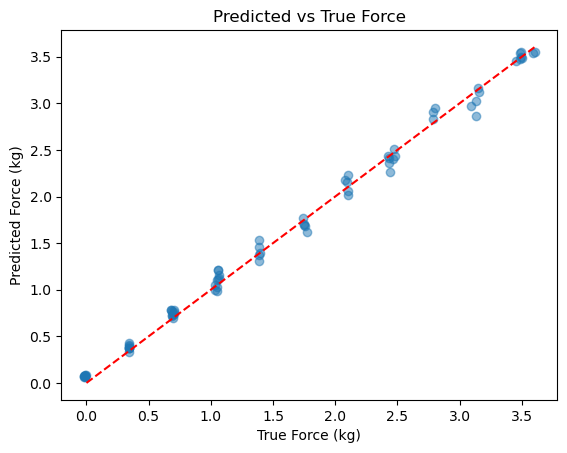

In [10]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, y_pred, alpha=0.5)
max_force = max(np.max(Y_test), np.max(y_pred))  # set axis range dynamically
plt.plot([0, max_force], [0, max_force], 'r--')  # y=x line
plt.xlabel("True Force (kg)")
plt.ylabel("Predicted Force (kg)")
plt.title("Predicted vs True Force")
plt.show()
